In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../artifacts/sentiment_analysis.csv")

In [3]:
data.head()

,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


In [4]:
len(data['tweet'])

7920

In [5]:
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(data, test_size=0.2,random_state=42)
len(train_data)

6336

In [6]:
len(test_data)

1584

## Explotary Data Analysis

### Data Preprocessing

In [7]:
## check the dataset shape

In [8]:
train_data.shape

(6336, 3)

In [9]:
## check the duplicate entries

In [10]:
train_data.duplicated().sum()

0

In [11]:
## check the null values of the dataset

In [12]:
train_data.isnull().sum()

id       0
label    0
tweet    0
dtype: int64

#### Text Preprocessing

In [13]:
import re
import string

In [14]:
train_data['tweet'].head()

4252    Cool Car wash idea #TheIsland #BankHolidayMond...
4428    Photo: 35th #Birthday to the #Sony #walkman @t...
7374    iPads are the biggest pile of fucking $&@*# on...
1410    Yearbook? Hmmmmm #instagram #instagood #togeth...
7896    So pissed! Macbook crashes, Apple Company does...
Name: tweet, dtype: object

In [15]:
## Convert uppercase into lowercase

In [16]:
train_data['tweet']=train_data['tweet'].apply(lambda x: " ".join(x.lower() for x in x.split()))

In [17]:
train_data['tweet'].head()

4252    cool car wash idea #theisland #bankholidaymond...
4428    photo: 35th #birthday to the #sony #walkman @t...
7374    ipads are the biggest pile of fucking $&@*# on...
1410    yearbook? hmmmmm #instagram #instagood #togeth...
7896    so pissed! macbook crashes, apple company does...
Name: tweet, dtype: object

In [18]:
## Remove the links

In [19]:
train_data['tweet']=train_data['tweet'].apply(lambda x: " ".join(re.sub(r'^https?:\/\/.*[\r\n]*','', x,flags=re.MULTILINE) for x in x.split()))

In [20]:
train_data['tweet']

4252    cool car wash idea #theisland #bankholidaymond...
4428    photo: 35th #birthday to the #sony #walkman @t...
7374    ipads are the biggest pile of fucking $&@*# on...
1410    yearbook? hmmmmm #instagram #instagood #togeth...
7896    so pissed! macbook crashes, apple company does...
                              ...                        
5226    #shana #tova!!! #jewish #newyear everyone, may...
5390    i'm so sick of buying new cell phone chargers....
860     it, want it, have it! download the free #iphon...
7603    photo: #nikosx #iphone #beach #holiday #bw #ip...
7270    just got an iphone 4s :) hehe #iphone #apple #...
Name: tweet, Length: 6336, dtype: object

In [21]:
## Remove punctuations

In [22]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [23]:
def remove_punctuations(text):
    for punctuation in string.punctuation:
        text =text.replace(punctuation, '')
    return text

train_data["tweet"]= train_data["tweet"].apply(remove_punctuations) 


In [24]:
train_data["tweet"].head()

4252    cool car wash idea theisland bankholidaymonday...
4428    photo 35th birthday to the sony walkman thinkg...
7374    ipads are the biggest pile of fucking  on the ...
1410    yearbook hmmmmm instagram instagood together f...
7896    so pissed macbook crashes apple company does n...
Name: tweet, dtype: object

In [25]:
## Remove the numbers from the text

In [26]:
train_data["tweet"]=train_data["tweet"].str.replace('/d+','', regex=True)

In [27]:
train_data["tweet"].tail()

5226    shana tova jewish newyear everyone may your ne...
5390    im so sick of buying new cell phone chargers a...
860     it want it have it download the free iphone ap...
7603    photo nikosx iphone beach holiday bw iphone4 b...
7270    just got an iphone 4s  hehe iphone apple new f...
Name: tweet, dtype: object

In [28]:
## Remove stop words

In [29]:
import nltk

In [30]:
nltk.download('stopwords', download_dir='../static/model/')

[nltk_data] Downloading package stopwords to ../static/model/...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
with open ('../static/model/corpora/stopwords/english', 'r') as file:
    sw=file.read().splitlines()

In [32]:
sw

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [33]:
train_data["tweet"]= train_data["tweet"].apply(lambda x: " ".join(x for x in x.split() if x not in sw))

In [34]:
train_data["tweet"].head()

4252    cool car wash idea theisland bankholidaymonday...
4428    photo 35th birthday sony walkman thinkgeek nob...
7374    ipads biggest pile fucking planet want throw f...
1410    yearbook hmmmmm instagram instagood together f...
7896    pissed macbook crashes apple company nothing a...
Name: tweet, dtype: object

In [35]:
## stemming

In [36]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()


In [37]:
train_data["tweet"]= train_data["tweet"].apply(lambda x: " ".join(ps.stem(x) for x in x.split()))

In [38]:
train_data["tweet"].head()

4252    cool car wash idea theisland bankholidaymonday...
4428    photo 35th birthday soni walkman thinkgeek nob...
7374    ipad biggest pile fuck planet want throw fuck ...
1410    yearbook hmmmmm instagram instagood togeth fri...
7896    piss macbook crash appl compani noth appl macb...
Name: tweet, dtype: object

In [39]:
## print the training dataset

In [40]:
train_data

,id,label,tweet
4252,4253,0,cool car wash idea theisland bankholidaymonday...
4428,4429,0,photo 35th birthday soni walkman thinkgeek nob...
7374,7375,1,ipad biggest pile fuck planet want throw fuck ...
1410,1411,0,yearbook hmmmmm instagram instagood togeth fri...
7896,7897,1,piss macbook crash appl compani noth appl macb...
...,...,...,...
5226,5227,0,shana tova jewish newyear everyon may new year...
5390,5391,1,im sick buy new cell phone charger appl
860,861,0,want download free iphon app today spread styl...
7603,7604,0,photo nikosx iphon beach holiday bw iphone4 bl...


## Building the vocabulary

In [41]:
from  collections import Counter
vocab = Counter()

In [42]:
vocab

Counter()

In [43]:
for sentence in train_data['tweet']:
    vocab.update(sentence.split())

In [44]:
len(vocab)

14626

In [45]:
train_data.shape

(6336, 3)

In [46]:
tokens = [key for key in vocab if vocab[key]>10]

In [47]:
len(tokens)

999

In [48]:
def save_vocabulary(lines, filename):
    data = '\n'.join(lines)
    file = open(filename, 'w', encoding="utf-8")
    file.write(data)
    file.close()

save_vocabulary(tokens, '../static/model/vocabulary.txt')


In [49]:
## Divide the dataset

In [50]:
x= train_data['tweet']
y=train_data['label']

In [51]:
x

4252    cool car wash idea theisland bankholidaymonday...
4428    photo 35th birthday soni walkman thinkgeek nob...
7374    ipad biggest pile fuck planet want throw fuck ...
1410    yearbook hmmmmm instagram instagood togeth fri...
7896    piss macbook crash appl compani noth appl macb...
                              ...                        
5226    shana tova jewish newyear everyon may new year...
5390              im sick buy new cell phone charger appl
860     want download free iphon app today spread styl...
7603    photo nikosx iphon beach holiday bw iphone4 bl...
7270    got iphon 4s hehe iphon appl new final seb0912...
Name: tweet, Length: 6336, dtype: object

In [52]:
y

4252    0
4428    0
7374    1
1410    0
7896    1
       ..
5226    0
5390    1
860     0
7603    0
7270    1
Name: label, Length: 6336, dtype: int64

In [53]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [54]:
x_train.shape

(5068,)

In [55]:
x_test.shape

(1268,)

In [56]:
## convert the text into numerical values

In [57]:
import numpy as np

def vectorizer(ds, vocabulary):
    vectorizer_list = []
    vocab_set = set(vocabulary)  # Use a set for faster lookup
    
    for sentence in ds:
        sentence_list = np.zeros(len(vocabulary), dtype=np.float16)  # Use np.float16 to reduce memory usage
        sentence_words = set(sentence.split())  # Split and convert sentence to a set to speed up membership checking
        
        for i, word in enumerate(vocabulary):
            if word in sentence_words:  # Check if word exists in the sentence
                sentence_list[i] = 1
                
        vectorizer_list.append(sentence_list)
    
    # Convert the list to a numpy array only once
    vectorizer_list_new = np.asarray(vectorizer_list, dtype=np.float16)
    
    return vectorizer_list_new


In [58]:
vectorized_x_train = vectorizer(x_train, tokens)


In [59]:
vectorized_x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float16)

In [60]:
vectorized_x_test = vectorizer(x_test,tokens)

In [61]:
vectorized_x_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float16)

In [62]:
## check the value counts of the y_train

In [63]:
y_train.value_counts()

label
0    3786
1    1282
Name: count, dtype: int64

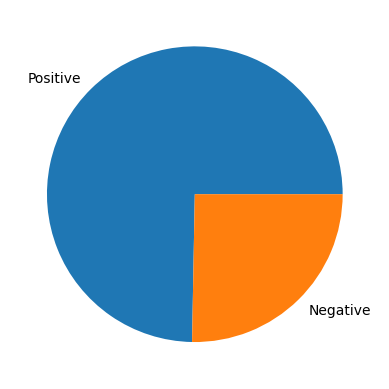

In [64]:
plt.pie(np.array([y_train.value_counts()[0], y_train.value_counts()[1]]), labels=["Positive","Negative"])
plt.show()

## Handling the Imbalance Dataset

In [65]:
! pip install imbalanced-learn

In [66]:
from imblearn.over_sampling import SMOTE
smote =SMOTE()
vectorized_x_train_smote,y_train_smote = smote.fit_resample(vectorized_x_train,y_train)
print(vectorized_x_train_smote.shape,y_train_smote.shape)

(7572, 999) (7572,)


In [67]:
y_train_smote.value_counts()

label
0    3786
1    3786
Name: count, dtype: int64

In [68]:
y_train_smote

0       0
1       0
2       0
3       1
4       0
       ..
7567    1
7568    1
7569    1
7570    1
7571    1
Name: label, Length: 7572, dtype: int64

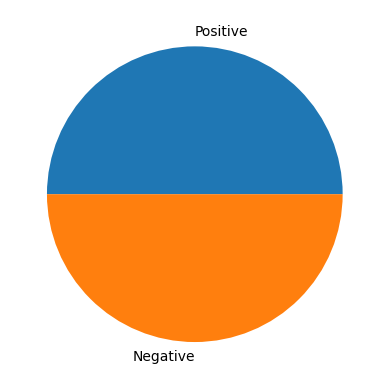

In [69]:
plt.pie(np.array([y_train_smote.value_counts()[0],y_train_smote.value_counts()[1]]), labels=['Positive','Negative'])
plt.show()

## Model Training And Model Evaluvation

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

### Logistic Regression

In [71]:
lr =LogisticRegression()
lr.fit(vectorized_x_train_smote,y_train_smote)

LogisticRegression()

In [72]:
y_train_pred= lr.predict(vectorized_x_train_smote)
y_train_pred

array([0, 0, 0, ..., 1, 0, 1], dtype=int64)

In [73]:
y_train_smote

0       0
1       0
2       0
3       1
4       0
       ..
7567    1
7568    1
7569    1
7570    1
7571    1
Name: label, Length: 7572, dtype: int64

In [74]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [75]:
print("Accuracy \t", accuracy_score(y_train_smote,y_train_pred) )
print("confusion matrix \n\t",confusion_matrix(y_train_smote, y_train_pred))
print("classification report ", classification_report(y_train_smote,y_train_pred))
    

Accuracy 	 0.9381933438985737
confusion matrix 
	 [[3428  358]
 [ 110 3676]]
classification report                precision    recall  f1-score   support

           0       0.97      0.91      0.94      3786
           1       0.91      0.97      0.94      3786

    accuracy                           0.94      7572
   macro avg       0.94      0.94      0.94      7572
weighted avg       0.94      0.94      0.94      7572



In [76]:
y_test_pred = lr.predict(vectorized_x_test)
y_test_pred

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [77]:
print("Accuracy \t", accuracy_score(y_test,y_test_pred) )
print("confusion matrix \n\t",confusion_matrix(y_test, y_test_pred))
print("classification report ", classification_report(y_test,y_test_pred))
    

Accuracy 	 0.8588328075709779
confusion matrix 
	 [[833 123]
 [ 56 256]]
classification report                precision    recall  f1-score   support

           0       0.94      0.87      0.90       956
           1       0.68      0.82      0.74       312

    accuracy                           0.86      1268
   macro avg       0.81      0.85      0.82      1268
weighted avg       0.87      0.86      0.86      1268



## Naive Bayes 

In [78]:
nb = MultinomialNB()
nb.fit(vectorized_x_train_smote,y_train_smote)

MultinomialNB()

In [79]:
y_train_pred= nb.predict(vectorized_x_train_smote)
y_train_pred

array([0, 1, 0, ..., 1, 0, 1], dtype=int64)

In [80]:
y_train_smote

0       0
1       0
2       0
3       1
4       0
       ..
7567    1
7568    1
7569    1
7570    1
7571    1
Name: label, Length: 7572, dtype: int64

In [81]:
print("Accuracy \t", accuracy_score(y_train_smote,y_train_pred) )
print("confusion matrix \n\t",confusion_matrix(y_train_smote, y_train_pred))
print("classification report ", classification_report(y_train_smote,y_train_pred))

Accuracy 	 0.8997622820919176
confusion matrix 
	 [[3214  572]
 [ 187 3599]]
classification report                precision    recall  f1-score   support

           0       0.95      0.85      0.89      3786
           1       0.86      0.95      0.90      3786

    accuracy                           0.90      7572
   macro avg       0.90      0.90      0.90      7572
weighted avg       0.90      0.90      0.90      7572



In [82]:
y_test_pred = nb.predict(vectorized_x_test)
y_test_pred

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

In [83]:
print("Accuracy \t", accuracy_score(y_test,y_test_pred) )
print("confusion matrix \n\t",confusion_matrix(y_test, y_test_pred))
print("classification report ", classification_report(y_test,y_test_pred))

Accuracy 	 0.8659305993690851
confusion matrix 
	 [[816 140]
 [ 30 282]]
classification report                precision    recall  f1-score   support

           0       0.96      0.85      0.91       956
           1       0.67      0.90      0.77       312

    accuracy                           0.87      1268
   macro avg       0.82      0.88      0.84      1268
weighted avg       0.89      0.87      0.87      1268



## DecisionTreeClassifier

In [84]:
dt_clf = DecisionTreeClassifier()
dt_clf.fit(vectorized_x_train_smote,y_train_smote)

DecisionTreeClassifier()

In [85]:
y_train_pred = dt_clf.predict(vectorized_x_train_smote)
y_train_pred

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [86]:
print("Accuracy \t", accuracy_score(y_train_smote,y_train_pred) )
print("confusion matrix \n\t",confusion_matrix(y_train_smote, y_train_pred))
print("classification report ", classification_report(y_train_smote,y_train_pred))

Accuracy 	 0.9993396724775488
confusion matrix 
	 [[3786    0]
 [   5 3781]]
classification report                precision    recall  f1-score   support

           0       1.00      1.00      1.00      3786
           1       1.00      1.00      1.00      3786

    accuracy                           1.00      7572
   macro avg       1.00      1.00      1.00      7572
weighted avg       1.00      1.00      1.00      7572



In [87]:
y_test_pred = dt_clf.predict(vectorized_x_test)
y_test_pred

array([0, 0, 0, ..., 1, 0, 0], dtype=int64)

In [88]:
print("Accuracy \t", accuracy_score(y_test,y_test_pred) )
print("confusion matrix \n\t",confusion_matrix(y_test, y_test_pred))
print("classification report ", classification_report(y_test,y_test_pred))

Accuracy 	 0.8028391167192429
confusion matrix 
	 [[835 121]
 [129 183]]
classification report                precision    recall  f1-score   support

           0       0.87      0.87      0.87       956
           1       0.60      0.59      0.59       312

    accuracy                           0.80      1268
   macro avg       0.73      0.73      0.73      1268
weighted avg       0.80      0.80      0.80      1268



## RandomForestClassifier

In [89]:
rf_clf = RandomForestClassifier()
rf_clf.fit(vectorized_x_train_smote,y_train_smote)

RandomForestClassifier()

In [90]:
y_train_pred = rf_clf.predict(vectorized_x_train_smote)
y_train_pred

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [91]:
print("Accuracy \t", accuracy_score(y_train_smote,y_train_pred) )
print("confusion matrix \n\t",confusion_matrix(y_train_smote, y_train_pred))
print("classification report ", classification_report(y_train_smote,y_train_pred))

Accuracy 	 0.9993396724775488
confusion matrix 
	 [[3786    0]
 [   5 3781]]
classification report                precision    recall  f1-score   support

           0       1.00      1.00      1.00      3786
           1       1.00      1.00      1.00      3786

    accuracy                           1.00      7572
   macro avg       1.00      1.00      1.00      7572
weighted avg       1.00      1.00      1.00      7572



In [92]:
y_test_pred = rf_clf.predict(vectorized_x_test)
y_test_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [93]:
print("Accuracy \t", accuracy_score(y_test,y_test_pred) )
print("confusion matrix \n\t",confusion_matrix(y_test, y_test_pred))
print("classification report ", classification_report(y_test,y_test_pred))

Accuracy 	 0.8564668769716088
confusion matrix 
	 [[874  82]
 [100 212]]
classification report                precision    recall  f1-score   support

           0       0.90      0.91      0.91       956
           1       0.72      0.68      0.70       312

    accuracy                           0.86      1268
   macro avg       0.81      0.80      0.80      1268
weighted avg       0.85      0.86      0.86      1268



## Support Vector Classifier

In [94]:
svc = SVC()
svc.fit(vectorized_x_train_smote,y_train_smote)

SVC()

In [95]:
y_train_pred= svc.predict(vectorized_x_train_smote)
y_train_pred

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [96]:
print("Accuracy \t", accuracy_score(y_train_smote,y_train_pred) )
print("confusion matrix \n\t",confusion_matrix(y_train_smote, y_train_pred))
print("classification report ", classification_report(y_train_smote,y_train_pred))

Accuracy 	 0.9766244057052298
confusion matrix 
	 [[3621  165]
 [  12 3774]]
classification report                precision    recall  f1-score   support

           0       1.00      0.96      0.98      3786
           1       0.96      1.00      0.98      3786

    accuracy                           0.98      7572
   macro avg       0.98      0.98      0.98      7572
weighted avg       0.98      0.98      0.98      7572



In [97]:
y_test_pred = svc.predict(vectorized_x_test)
y_test_pred

array([0, 0, 0, ..., 0, 1, 0], dtype=int64)

In [98]:
print("Accuracy \t", accuracy_score(y_test,y_test_pred) )
print("confusion matrix \n\t",confusion_matrix(y_test, y_test_pred))
print("classification report ", classification_report(y_test,y_test_pred))

Accuracy 	 0.8659305993690851
confusion matrix 
	 [[860  96]
 [ 74 238]]
classification report                precision    recall  f1-score   support

           0       0.92      0.90      0.91       956
           1       0.71      0.76      0.74       312

    accuracy                           0.87      1268
   macro avg       0.82      0.83      0.82      1268
weighted avg       0.87      0.87      0.87      1268



## Hyper Paramter Tuning and Grid Search CV

In [99]:
from sklearn.model_selection import GridSearchCV

In [100]:
## logistic regression

In [101]:
#param_lr_grid = {
 #   'penalty': ['l1', 'l2', 'elasticnet'],
  #  'solver': ['liblinear', 'saga'],  # 
   # 'max_iter': [100, 200, 500]  
#}


In [102]:
#logistic_regression_grid_search = GridSearchCV(estimator=lr, param_grid=param_lr_grid)
#logistic_regression_grid_search.fit(vectorized_x_train_smote,y_train_smote)

In [103]:
#logistic_regression_grid_search.best_params_

In [104]:
#logistic_regression_grid_search_prediction = logistic_regression_grid_search.predict(vectorized_x_test)
#logistic_regression_grid_search_prediction

In [105]:
#logistic_regression_grid_search_accuracy = accuracy_score(y_test, logistic_regression_grid_search_prediction)
#logistic_regression_grid_search_accuracy

In [106]:
#parameter_nb_grid = {'class_count':['alpha', 'class_prior', 'fit_prior', 'force_alpha']}

In [107]:
#naive_bayes_grid_search_cv =GridSearchCV(estimator=nb, param_grid=parameter_nb_grid)
#naive_bayes_grid_search_cv.fit(vectorized_x_train_smote,y_train_smote)

## Save and Load the file

In [108]:
import pickle
with open('../static/model/model.pkl', 'wb') as file:
    pickle.dump(lr,file)